A walkthrough of one question: **when Greenpoint/Williamsburg residents show
up to a Community Board 1 meeting, does it change how the board votes?**

The answer turns out to be precise, and not the one either cynics or
organizers would guess: *turnout does not flip votes - but it is strongly
tied to when the board splits, and what conditions get attached.* This
notebook builds that answer in five steps:

1. **Baseline** - across ~1,150 tallied votes, which topics does the board
   fight about at all?
2. **A paradox** - parks are the board's most consensual topic, yet the
   park saga contains the decade's two biggest fights.
3. **The waterfront panel** - 26 waterfront development votes, classified
   as *advocacy* vs *application*, joined to public testimony.
4. **The mechanism** - the board only splits when a developer application
   forces a choice, and turnout tracks exactly those moments.
5. **Robustness & what it means** - the result survives every reasonable
   variation of the design choices, and it has a practical reading.

Data: the CB1 minutes dataset (110 meetings, 2016-2026) extracted from the
official PDFs; every record carries a verbatim source snippet. This analysis
depends on `data/vote_overrides.json` - the September 2021 River Ring
roll-call section was misfiled as an attachment by the pipeline and its votes
were recovered by hand from the minutes text (documented in that file).
Condensed from Models 2 and 4 in `regressions.ipynb`.

In [1]:
import re

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu, spearmanr

con = duckdb.connect()
for t in ("meetings", "licenses", "votes", "speakers"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '../data/db/{t}.parquet'")

def q(sql):
    return con.execute(sql).df()

SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLUE, RED, GRAY = "#2a78d6", "#e34948", "#a5a49e"

## 1. Baseline: what does the board fight about?

A vote is *contested* if at least one member voted no (voice votes are
excluded - there is no tally to contest). First the raw rates by topic.

In [2]:
rates = q("""
    SELECT topic_category, count(*) AS n,
           round(avg(CASE WHEN no > 0 THEN 1 ELSE 0 END), 3) AS contested_rate,
           round(stddev_samp(CASE WHEN no > 0 THEN 1 ELSE 0 END), 3) AS std_dev
    FROM votes WHERE yes + no > 0
    GROUP BY 1 ORDER BY contested_rate DESC
""")
rates

,topic_category,n,contested_rate,std_dev
0,land_use,174,0.305,0.462
1,liquor,293,0.294,0.456
2,budget,29,0.207,0.412
3,transportation,165,0.194,0.397
4,other,140,0.157,0.365
5,internal,228,0.118,0.324
6,parks,59,0.085,0.281
7,environment,67,0.045,0.208


Land use and liquor draw fights three times out of ten; parks and
environment almost never. A logistic regression makes that comparison
honest - it holds attendance and year constant, uses liquor (the modal
topic) as the reference category, and clusters standard errors by meeting,
because the votes of one night are not independent observations.

Coefficients are exponentiated into **odds ratios**: OR = 0.25 means "a
quarter the odds of drawing a no vote, relative to a liquor motion".

In [3]:
v2 = q("""
    SELECT v.meeting_id, year(m.date) AS yr, v.topic_category,
           m.attendance_count,
           CASE WHEN v.no > 0 THEN 1 ELSE 0 END AS contested
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE v.yes + v.no > 0 AND m.attendance_count IS NOT NULL
""")
v2["topic"] = v2.topic_category.where(
    v2.topic_category.isin(
        ["land_use", "liquor", "transportation", "internal", "parks"]),
    "other")
m2 = smf.logit(
    "contested ~ C(topic, Treatment('liquor')) + attendance_count + I(yr - 2016)",
    data=v2).fit(disp=0, cov_type="cluster", cov_kwds={"groups": v2.meeting_id})
or2 = pd.DataFrame({
    "odds_ratio": np.exp(m2.params),
    "ci_low": np.exp(m2.conf_int()[0]),
    "ci_high": np.exp(m2.conf_int()[1]),
    "p": m2.pvalues,
}).round(3)
print(f"{len(v2)} votes, base contested rate {v2.contested.mean():.1%}")
or2

1150 votes, base contested rate 20.3%


,odds_ratio,ci_low,ci_high,p
Intercept,0.810,0.279,2.351,0.698
"C(topic, Treatment('liquor'))[T.internal]",0.321,0.127,0.810,0.016
"C(topic, Treatment('liquor'))[T.land_use]",1.061,0.452,2.493,0.892
"C(topic, Treatment('liquor'))[T.other]",0.392,0.149,1.031,0.058
"C(topic, Treatment('liquor'))[T.parks]",0.230,0.072,0.731,0.013
"C(topic, Treatment('liquor'))[T.transportation]",0.609,0.232,1.599,0.314
attendance_count,0.977,0.929,1.027,0.357
I(yr - 2016),0.993,0.911,1.083,0.877


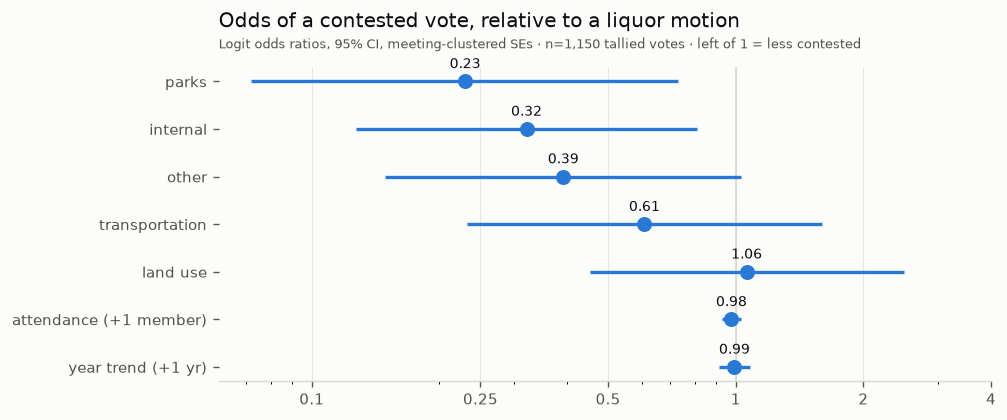

In [4]:
LABELS = {
    "C(topic, Treatment('liquor'))[T.parks]": "parks",
    "C(topic, Treatment('liquor'))[T.internal]": "internal",
    "C(topic, Treatment('liquor'))[T.other]": "other",
    "C(topic, Treatment('liquor'))[T.transportation]": "transportation",
    "C(topic, Treatment('liquor'))[T.land_use]": "land use",
    "attendance_count": "attendance (+1 member)",
    "I(yr - 2016)": "year trend (+1 yr)",
}
rows = or2.loc[list(LABELS)].rename(index=LABELS)

fig, ax = plt.subplots(figsize=(8.5, 3.6), dpi=120)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ys = np.arange(len(rows))[::-1]
ax.axvline(1, color="#d8d7d2", lw=1)
ax.hlines(ys, rows.ci_low, rows.ci_high, color=BLUE, lw=2)
ax.plot(rows.odds_ratio, ys, "o", ms=8, color=BLUE, zorder=3)
for y, (name, r) in zip(ys, rows.iterrows()):
    ax.annotate(f"{r.odds_ratio:.2f}", (r.odds_ratio, y), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=8.5, color=INK)
ax.set_yticks(ys, rows.index, fontsize=9.5)
ax.set_xscale("log")
ax.set_xticks([0.1, 0.25, 0.5, 1, 2, 4], ["0.1", "0.25", "0.5", "1", "2", "4"])
ax.tick_params(colors=INK2, labelsize=9)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
ax.grid(axis="x", color="#e8e7e2", lw=0.7); ax.set_axisbelow(True)
ax.set_title("Odds of a contested vote, relative to a liquor motion",
             fontsize=12, color=INK, loc="left", pad=24)
ax.text(0, 1.06, "Logit odds ratios, 95% CI, meeting-clustered SEs · n=1,150 tallied votes · left of 1 = less contested",
        transform=ax.transAxes, fontsize=8, color=INK2)
plt.tight_layout(); plt.show()

**Reading it:** parks motions have less than a quarter the odds of
drawing a no vote (OR 0.23, p=.013). And the two nulls matter as much as the
effect: attendance does nothing, and there is **no year trend** - the board
has not grown more combative over the decade. Fights follow topics, not
times.

## 2. The paradox

So parks are the most consensual thing CB1 does. Yet anyone following the
Bushwick Inlet Park story knows the waterfront produced the two biggest
fights of the decade - River Ring (2021) and Monitor Point (2026).

The resolution: those fights were never *parks motions*. They were
**land-use applications on waterfront parcels** - filed by developers,
categorized `land_use`, and forcing the board to choose between the
community's park ask and something else it also wants (housing, jobs, a
school, union work). The next section separates those two kinds of vote
explicitly.

## 3. The waterfront panel

26 votes (2016-2026) whose motion text matches the waterfront storyline
(Bushwick Inlet, Monitor Point, River Ring, Quay, esplanade, demapping, ...),
excluding one false match (a Link5G motion that mentions "waterfront
locations"). Three design choices:

- **kind** - *advocacy* (board-initiated letters and funding asks) vs
  *application* (a response to a developer's ULURP/CEQR filing), classified
  from the motion text.
- **division** - the minority share of the tally, direction-agnostic.
  A deny motion failing 12-20 is a *pro-project* outcome; reading no-votes
  as opposition would get the sign backwards.
- **spk90** - waterfront-topic public-session speakers at the same meeting
  or in the 90 days before it, because hearings precede votes (the January
  2026 Monitor Point hearing fed the February 2026 vote).

In [5]:
WF = ("(bushwick inlet|monitor point|river ring|quay|65 commercial|56 quay|"
      "40 quay|waterfront|esplanade|demapp|marsha p|inlet park|fbip|open space)")

wfv = q(f"""
    SELECT v.meeting_id, m.date, v.motion_text, v.topic_category,
           v.yes, v.no, v.abstain, v.outcome, len(v.conditions) AS n_cond
    FROM votes v JOIN meetings m USING (meeting_id)
    WHERE v.topic_category IN ('land_use','parks','environment')
      AND regexp_matches(lower(v.motion_text), '{WF}')
      AND NOT regexp_matches(lower(v.motion_text), 'link5g')
      AND v.yes + v.no > 0
    ORDER BY date
""")
tot = wfv.yes + wfv.no + wfv.abstain
wfv["division"] = (tot - wfv[["yes", "no"]].max(axis=1)) / tot
APP = re.compile(r"application|ulurp|ceqr|proposal|scoping|design|demapp", re.I)
wfv["kind"] = wfv.motion_text.map(
    lambda t: "application" if APP.search(t) else "advocacy")
wfv["date"] = pd.to_datetime(wfv.date)

wfs = q(f"""
    SELECT m.date, s.position FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE regexp_matches(lower(s.topic), '{WF}')
""")
wfs["date"] = pd.to_datetime(wfs.date)
wfv["spk90"] = wfv.date.map(
    lambda d: ((d - wfs.date).dt.days.between(0, 90)).sum())

wfv[["date", "topic_category", "kind", "yes", "no", "abstain", "n_cond", "division", "spk90"]]

,date,topic_category,kind,yes,no,abstain,n_cond,division,spk90
0,2016-06-14,parks,advocacy,39,0,0,0,0.000000,1
1,2019-06-11,environment,advocacy,36,0,0,0,0.000000,0
2,2019-11-12,parks,advocacy,38,0,0,0,0.000000,0
3,2020-02-11,parks,application,33,0,0,6,0.000000,0
4,2020-06-24,parks,application,28,0,0,0,0.000000,0
5,2020-10-13,parks,advocacy,29,0,0,0,0.000000,2
6,2021-01-12,parks,application,47,0,0,1,0.000000,11
7,2021-01-12,parks,advocacy,47,0,0,1,0.000000,11
8,2021-02-09,parks,advocacy,30,0,0,0,0.000000,12
9,2021-03-09,parks,application,30,0,0,4,0.000000,19


## 4. The mechanism

Two summaries carry the whole result: division by kind, and the rank
correlation between turnout and division.

In [6]:
for k in ("application", "advocacy"):
    g = wfv[wfv.kind == k]
    print(f"{k:12} n={len(g):>2}  divided={(g.division > 0).sum()}  "
          f"mean division={g.division.mean():.1%}  conditions={g.n_cond.sum()}")

rho, p = spearmanr(wfv.spk90, wfv.division)
print(f"\nturnout vs division (all votes):     rho={rho:.2f}  p={p:.4f}")
ga = wfv[wfv.kind == "application"]
rho, p = spearmanr(ga.spk90, ga.division)
print(f"turnout vs division (applications):  rho={rho:.2f}  p={p:.4f}")
rho, p = spearmanr(wfv.spk90, wfv.n_cond)
print(f"turnout vs conditions attached:      rho={rho:.2f}  p={p:.4f}")

a, b = wfv[wfv.spk90 > 0], wfv[wfv.spk90 == 0]
mw = mannwhitneyu(a.division, b.division, alternative="greater")
print(f"division when testimony within 90d ({len(a)}) vs quiet ({len(b)}): "
      f"{a.division.mean():.1%} vs {b.division.mean():.1%}  (MW p={mw.pvalue:.3f})")

application  n=15  divided=6  mean division=12.3%  conditions=49
advocacy     n=11  divided=1  mean division=0.2%  conditions=2

turnout vs division (all votes):     rho=0.53  p=0.0058
turnout vs division (applications):  rho=0.64  p=0.0096
turnout vs conditions attached:      rho=0.36  p=0.0679
division when testimony within 90d (18) vs quiet (8): 10.2% vs 0.3%  (MW p=0.107)


### The virtual channel

The mic is not the only way input arrives: residents write in, and the
letters and emails get bound into the meeting packet as attachments. Those
are countable: split the attachment pages at correspondence boundaries
(forwarded-email headers, letter salutations like "Dear Chair...") and count
an item as waterfront if a waterfront term appears within it.

Two things this series is *not*: it has no stance (we do not extract
for/against from letters), and it is not comparable before ~2022 - earlier
packets simply did not include correspondence, so early zeros are archival
silence, not civic silence. It is plotted as its own channel, hatched, and
kept out of the statistical panel.

In [7]:
import json
from pathlib import Path

_meet = json.loads(Path("../data/meetings.json").read_text())["meetings"]
BOUND = re.compile(
    r"From: [A-Z][A-Za-z .\u2019'-]{3,40}? Sent: |"
    r"Dear (?:Chair|Chairperson|Community Board|CB ?1|Members|Board|Mr\.|Ms\.|"
    r"Sir|Madam|District Manager)|To Whom It May Concern", re.I)
WFC = re.compile(r"bushwick inlet|monitor point|river ring|quay|65 commercial|"
                 r"waterfront|esplanade|demapp|inlet park|marsha p", re.I)

_ocr = {}
for _of in Path("../data/interim/ocr").glob("*.txt"):
    sha, p = _of.stem.rsplit("-p", 1)
    _ocr.setdefault(sha, []).append((int(p), _of))

rows = []
for mid, m in _meet.items():
    att = ""
    for f in m["files"]:
        sha = f["sha256"]
        sf = Path(f"../data/interim/segments/{sha}.json")
        if not sf.exists():
            continue
        body = set(json.loads(sf.read_text())["body_pages"])
        tp = Path(f"../data/interim/text/{sha}.json")
        pages = json.loads(tp.read_text()) if tp.exists() else []
        att += " ".join(p for i, p in enumerate(pages) if i not in body)
        for pno, of in _ocr.get(sha, []):
            if pno not in body:
                att += " " + of.read_text()
    t = " ".join(att.split())
    idxs = [b.start() for b in BOUND.finditer(t)]
    wf_items = 0
    for j, st in enumerate(idxs):
        end = idxs[j + 1] if j + 1 < len(idxs) else min(st + 1500, len(t))
        if WFC.search(t[st:end]):
            wf_items += 1
    rows.append({"date": pd.Timestamp(m["date"]), "n_virtual": wf_items})
corr_pm = pd.DataFrame(rows).query("n_virtual > 0").sort_values("date")
print(f"{corr_pm.n_virtual.sum()} waterfront written comments across "
      f"{len(corr_pm)} meetings (packets include correspondence from ~2022)")
corr_pm.tail(8)

355 waterfront written comments across 42 meetings (packets include correspondence from ~2022)


,date,n_virtual
102,2025-12-09,1
103,2026-01-13,1
104,2026-01-20,67
105,2026-02-10,9
106,2026-03-10,7
107,2026-04-14,4
108,2026-05-12,1
109,2026-06-09,5


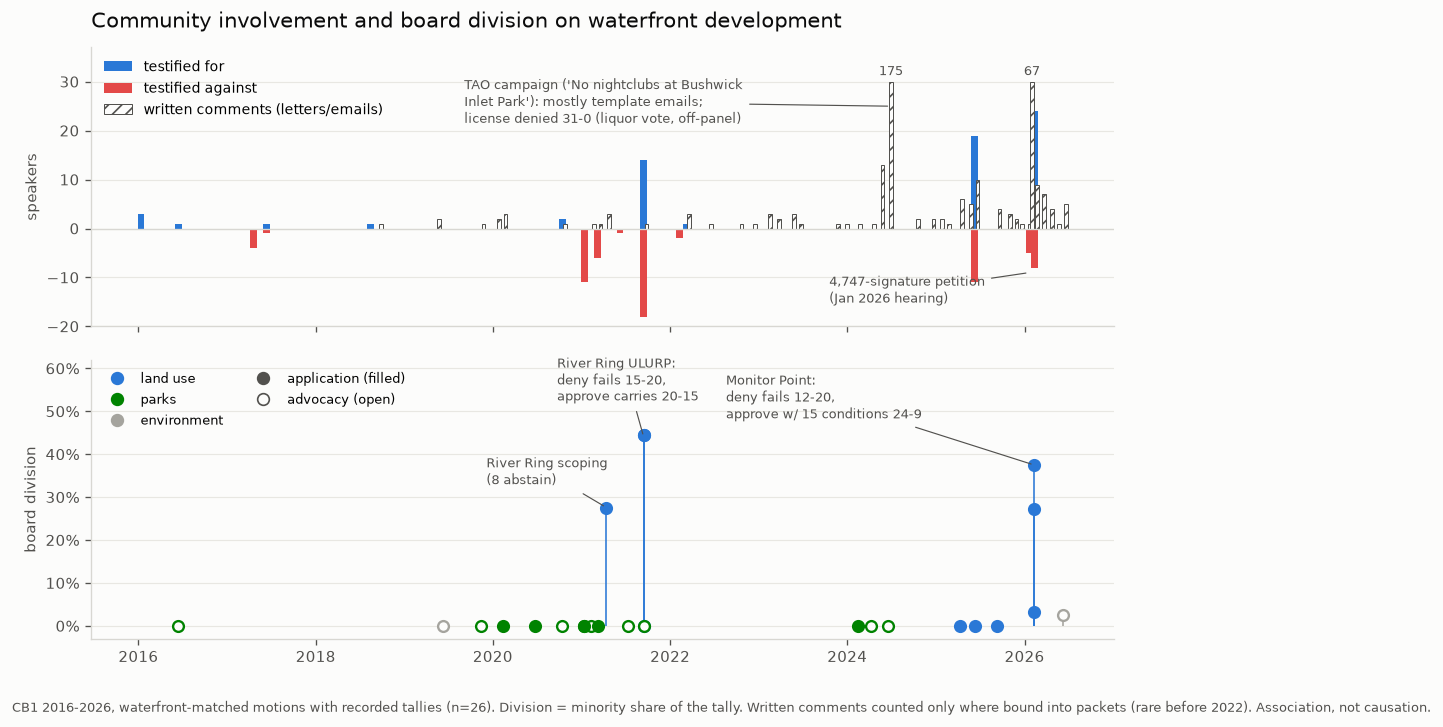

In [8]:
per_meet = q(f"""
    SELECT m.date,
           count(*) FILTER (s.position = 'for') AS n_for,
           count(*) FILTER (s.position = 'against') AS n_against
    FROM speakers s JOIN meetings m USING (meeting_id)
    WHERE regexp_matches(lower(s.topic), '{WF}')
    GROUP BY 1 ORDER BY 1
""")
per_meet["date"] = pd.to_datetime(per_meet.date)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 6.4), dpi=120, sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12})
fig.patch.set_facecolor(SURFACE)
W = 28  # bar width, days
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color("#d8d7d2")
    ax.spines["bottom"].set_color("#d8d7d2")
    ax.tick_params(colors=INK2, labelsize=9)

ax1.bar(per_meet.date, per_meet.n_for, width=W, color=BLUE, label="testified for")
ax1.bar(per_meet.date, -per_meet.n_against, width=W, color=RED,
        label="testified against")
VBAR = corr_pm.set_index("date").n_virtual
ax1.bar(VBAR.index + pd.Timedelta(days=11), VBAR.clip(upper=30), width=W * 0.55,
        facecolor=SURFACE, edgecolor=INK2, hatch="///", lw=0.6,
        label="written comments (letters/emails)")
for d, nv in VBAR[VBAR > 30].items():
    ax1.annotate(f"{nv}", (d + pd.Timedelta(days=11), 30.7), ha="center",
                 va="bottom", fontsize=8, color=INK2)
ax1.set_ylim(-20, 37)
ax1.axhline(0, color="#d8d7d2", lw=0.8)
ax1.set_ylabel("speakers", fontsize=9, color=INK2)
ax1.legend(loc="upper left", frameon=False, fontsize=8.5)
ax1.grid(axis="y", color="#e8e7e2", lw=0.7)
ax1.set_axisbelow(True)
ax1.annotate("4,747-signature petition\n(Jan 2026 hearing)",
             (pd.Timestamp("2026-01-20"), -9), xytext=(-120, -18),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax1.annotate("TAO campaign ('No nightclubs at Bushwick\nInlet Park'): mostly template emails;\nlicense denied 31-0 (liquor vote, off-panel)",
             (pd.Timestamp("2024-06-29"), 25), xytext=(-256, -10),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax1.set_title("Community involvement and board division on waterfront development",
              fontsize=12.5, color=INK, loc="left", pad=12)

GREEN = "#008300"
TOPIC_COLOR = {"land_use": BLUE, "parks": GREEN, "environment": GRAY}
for (topic, kind), g in wfv.groupby(["topic_category", "kind"]):
    color = TOPIC_COLOR[topic]
    face = color if kind == "application" else SURFACE
    ax2.vlines(g.date, 0, g.division, color=color, lw=1.2, alpha=0.8)
    ax2.scatter(g.date, g.division, s=42, facecolor=face, edgecolor=color,
                lw=1.4, zorder=3)
ax2.set_ylabel("board division", fontsize=9, color=INK2)
ax2.set_ylim(-0.03, 0.62)
ax2.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
from matplotlib.lines import Line2D
handles = [
    Line2D([], [], marker="o", ls="", mfc=BLUE, mec=BLUE, ms=7, label="land use"),
    Line2D([], [], marker="o", ls="", mfc=GREEN, mec=GREEN, ms=7, label="parks"),
    Line2D([], [], marker="o", ls="", mfc=GRAY, mec=GRAY, ms=7, label="environment"),
    Line2D([], [], marker="o", ls="", mfc=INK2, mec=INK2, ms=7, label="application (filled)"),
    Line2D([], [], marker="o", ls="", mfc=SURFACE, mec=INK2, ms=7, label="advocacy (open)"),
]
ax2.legend(handles=handles, loc="upper left", frameon=False, fontsize=8, ncol=2)
ax2.grid(axis="y", color="#e8e7e2", lw=0.7)
ax2.set_axisbelow(True)
ax2.annotate("River Ring scoping\n(8 abstain)", (pd.Timestamp("2021-04-13"), 0.276),
             xytext=(-72, 14), textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax2.annotate("River Ring ULURP:\ndeny fails 15-20,\napprove carries 20-15",
             (pd.Timestamp("2021-09-14"), 0.44), xytext=(-52, 22),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
ax2.annotate("Monitor Point:\ndeny fails 12-20,\napprove w/ 15 conditions 24-9",
             (pd.Timestamp("2026-02-10"), 0.375), xytext=(-185, 28),
             textcoords="offset points", fontsize=8, color=INK2,
             arrowprops=dict(arrowstyle="-", color=INK2, lw=0.7))
fig.text(0.065, 0.015,
         "CB1 2016-2026, waterfront-matched motions with recorded tallies (n=26). "
         "Division = minority share of the tally. Written comments counted only "
         "where bound into packets (rare before 2022). Association, not causation.",
         fontsize=8, color=INK2)
plt.show()

**Reading the figure.** The bottom panel's flat baseline from 2016
through 2020 is the *ritual decade*: waterfront advocacy motions passing
unanimously, year after year. Division appears exactly twice - the River
Ring cluster (2021) and the Monitor Point cluster (2026) - and both sit
directly under the two tallest testimony spikes in the top panel. Also
visible: turnout is not one-sided. At Monitor Point's February 2026 vote the
matched testimony ran 24 *for* / 8 *against* (union members supporting the
project), while the 4,747-signature petition ran against - "community
involvement" was on both sides of the room.

The color split resolves the Section 2 paradox at a glance: **every divided
vote is land use (blue)**. The fourteen parks motions (green) pass
unanimously down to the last vote - 14 for 14 - which is the waterfront
version of Model 2's district-wide finding (parks OR 0.23). The contentious
votes are not park questions; they are land-use questions *about* park
land.

One event sits outside both panels by construction: the June 2024 TAO
campaign ("Say 'No' To Nightclubs At Bushwick Inlet Park", 105 template
emails *plus* ten speakers whose extracted topics name the applicant, not
the park). The board denied that liquor license 31-0 the same night - the
community's one outright waterfront win in the dataset, and it happened on
the smallest, most specific decision on the ballot. That is Model 3's
address-specificity result wearing park colors.

The hatched bars are the written channel, and they invert the picture of the
Monitor Point era: at the January 2026 hearing only 5 matched speakers took
the mic, but the packet contains **67 written comments - every piece of
correspondence bound in that month was about the waterfront** (plus the
4,747-signature petition). By 2024-26 most community input arrives in
writing; a mic-only measure undercounts the mobilization several-fold. The
bars begin in 2022 because that is when the office began binding
correspondence into packets - absence before then is archival, not civic.

Note what turnout did **not** do: River Ring and Monitor Point were both
approved. The petition did not flip a vote. What high turnout coincides with
is (a) recorded splits - every member's name on a roll call - and (b)
conditions attached to approval (Monitor Point's 15, traced ask-by-ask to
testimony in `waterfront_saga.ipynb`).

## 5. Robustness: is this an artifact of the 90-day window?

The lookback window is the one free parameter in the design, so sweep it.

In [9]:
print(f"{'window':>8} {'div (all)':>16} {'div (apps)':>16} {'conditions':>16}")
for w in (30, 60, 90, 180):
    spk = wfv.date.map(lambda d: ((d - wfs.date).dt.days.between(0, w)).sum())
    is_app = wfv.kind == "application"
    r1, p1 = spearmanr(spk, wfv.division)
    r2, p2 = spearmanr(spk[is_app], wfv.division[is_app])
    r3, p3 = spearmanr(spk, wfv.n_cond)
    print(f"{w:>6}d  {r1:>6.2f} / {p1:.3f}  {r2:>6.2f} / {p2:.3f}  {r3:>6.2f} / {p3:.3f}")

  window        div (all)       div (apps)       conditions
    30d    0.46 / 0.019    0.56 / 0.029    0.41 / 0.040
    60d    0.53 / 0.006    0.64 / 0.010    0.36 / 0.068
    90d    0.53 / 0.006    0.64 / 0.010    0.36 / 0.068
   180d    0.64 / 0.000    0.66 / 0.008    0.17 / 0.420


The turnout-division relationship is significant at every window and
strengthens as the window widens - it is not an artifact of the 90-day
choice. The turnout-conditions correlation **is** window-sensitive (present
at 30 days, gone at 180), so the statistical claim for the conditions
channel is weak; the strong evidence for it is forensic, not statistical -
specific testimony demands reappearing verbatim as binding conditions.

## What this means

- **The board does not need pressure to vote for the park.** Advocacy
  motions pass unanimously with or without an audience (Model 2's parks
  OR 0.23 is the district-wide version of the same fact).
- **The leverage points are applications.** Division only exists when a
  developer filing forces the board to choose between the community's ask
  and something else it also wants. Those are the votes where showing up
  coincides with named roll calls and negotiated conditions.
- **Volume alone does not flip votes** - a 4,747-signature petition did
  not - but specificity converts: asks concrete enough to become
  conditions became conditions. (The liquor-side analog, Model 3 in
  `regressions.ipynb`: address-specific opposition triples denial odds;
  generic opposition does nothing.)

**Caveats.** n=26, and one night (Feb 2026) contributes three votes.
Everything is extraction-derived (tallies are gated by the golden-set eval;
topic matching is regex over extracted text). The statistical panel counts mic testimony only; written comments are
plotted as their own channel but not modeled - they carry no extracted
stance, and packets only include correspondence from ~2022, so the series
cannot support pre/post comparisons.
Spearman p-values are approximate under heavy ties. Association, not
causation, throughout.